# Phase 1 — Data Verification
- load a single liver NIfTI volume,
- apply MONAI transforms
- visualize a slice with its label overlaid

In [33]:
# ============================================================
# Imports
# Purpose:
#   Load MONAI, PyTorch, visualization, experiment tracking,
#   and medical imaging libraries used throughout the
#   liver/tumor segmentation pipeline.
#
# Key Libraries:
#   - MONAI: Medical imaging framework built on PyTorch
#   - PyTorch: Deep learning training/inference
#   - MLflow: Experiment tracking and model management
#   - Nibabel: Reading NIfTI (.nii.gz) medical image files
#   - Matplotlib: Visualization and qualitative evaluation
# ============================================================

from monai.utils import first, set_determinism
from monai.transforms import (
    AsDiscrete,
    EnsureChannelFirstd,
    Compose,
    CropForegroundd,
    LoadImaged,
    Orientationd,
    RandCropByPosNegLabeld,
    RandFlipd,
    ScaleIntensityRanged,
    Spacingd,
    KeepLargestConnectedComponent,
    SpatialPadd,
    EnsureTyped
)

from monai.handlers.utils import from_engine
from monai.networks.nets import UNet
from monai.networks.layers import Norm
from monai.metrics import DiceMetric
from monai.losses import DiceCELoss, TverskyLoss
from monai.inferers import sliding_window_inference
from monai.data import (
    CacheDataset,
    DataLoader,
    Dataset,
    decollate_batch,
    pad_list_data_collate
)

import matplotlib.patches as mpatches
from monai.config import print_config
from monai.apps import download_and_extract

from mlflow import MlflowException
from pathlib import Path

from flask import json

import torch
import matplotlib.pyplot as plt
import os
import glob
import numpy as np
import time
import mlflow
import nibabel as nib

# Display MONAI, PyTorch, and dependency versions
# Useful for reproducibility and debugging.
print_config()

MONAI version: 1.5.2
Numpy version: 2.4.4
Pytorch version: 2.6.0+cu124


MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: d:\Summer_Projects_2026\ct-segmentation-monai\summer_01_env\Lib\site-packages\monai\__init__.py

Optional dependencies:
Pytorch Ignite version: 0.4.11
ITK version: 5.4.6
Nibabel version: 5.4.2
scikit-image version: 0.26.0
scipy version: 1.17.1
Pillow version: 12.2.0
Tensorboard version: 2.20.0
gdown version: 6.0.0
TorchVision version: 0.21.0+cu124
tqdm version: 4.67.3
lmdb version: 2.2.0
psutil version: 7.2.2
pandas version: 2.3.3
einops version: 0.8.2
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: 3.12.0
pynrrd version: 1.1.3
clearml version: 2.1.7

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#installing-the-recommended-dependencies



In [34]:
# ============================================================
# Dataset Configuration
#
# Medical Segmentation Decathlon
# Task03_Liver:
#   - CT volumes (.nii.gz)
#   - Liver segmentation masks
#   - Tumor segmentation masks
#
# Directory Structure:
#   Task03_Liver/
#       imagesTr/
#       labelsTr/
# ============================================================

data_dir = r"C:\DataSets\Medical_Segmentation_Decathlon\Task03_Liver\Task03_Liver"

# Verify dataset exists before continuing.
# Prevents downstream file-loading errors.
if not os.path.exists(data_dir):
    # download_and_extract(resource, compressed_file, root_dir, md5)
    print(
        "Error: Data file not found. "
        "Please download the dataset manually and place it in the specified directory."
    )

In [35]:
# ============================================================
# Build Dataset File Index
#
# Creates a MONAI-compatible list of dictionaries:
#
# {
#     "image": <ct_scan_path>,
#     "label": <segmentation_mask_path>
# }
#
# These dictionaries are later consumed by MONAI Dataset
# and DataLoader objects.
# ============================================================

# Load all training CT volumes
train_images = sorted(
    glob.glob(os.path.join(data_dir, "imagesTr", "*.nii.gz"))
)

# Load corresponding segmentation masks
train_labels = sorted(
    glob.glob(os.path.join(data_dir, "labelsTr", "*.nii.gz"))
)

# Pair each CT scan with its ground-truth mask
data_dicts = [
    {"image": image_name, "label": label_name}
    for image_name, label_name in zip(train_images, train_labels)
]

# ------------------------------------------------------------
# Train / Validation Split
#
# Last 9 volumes reserved for validation.
# Remaining volumes used for training.
#
# NOTE:
# In production, a randomized split would typically be used.
# ------------------------------------------------------------

train_files, val_files = data_dicts[:-9], data_dicts[-9:]

# ============================================================
# Sanity Checks
#
# Verify:
#   1. File paths are correct
#   2. Files exist on disk
#   3. NIfTI volumes can be loaded successfully
# ============================================================

print(train_files[0]["image"])

path = train_files[0]["image"]
print(os.path.exists(path))

img = nib.load(train_files[0]["image"])
print(img.shape)

C:\DataSets\Medical_Segmentation_Decathlon\Task03_Liver\Task03_Liver\imagesTr\liver_0.nii.gz
True
(512, 512, 75)


In [36]:
# Fix random seed for reproducibility — ensures same train/val split
# and augmentations every run, making results comparable across experiments
set_determinism(seed=1)

In [37]:
# Data preprocessing and augmentation pipeline used during training.
# These transforms standardize CT scans, normalize voxel intensities,
# and generate random 3D patches to improve model generalization.

train_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),

        # Normalize CT intensity values to the range [0, 1]
        ScaleIntensityRanged(
            keys=["image"],
            a_min=-57,
            a_max=164,
            b_min=0.0,
            b_max=1.0,
            clip=True,
        ),

        # Remove unnecessary background regions
        CropForegroundd(
            keys=["image", "label"],
            source_key="image",
            allow_smaller=True,
        ),

        # Standardize scan orientation and voxel spacing
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        Spacingd(
            keys=["image", "label"],
            pixdim=(1.5, 1.5, 2.0),
            mode=("bilinear", "nearest"),
        ),

        EnsureTyped(keys=["label"], dtype=torch.long),

        # Sample balanced training patches containing both
        # foreground (liver/tumor) and background voxels
        RandCropByPosNegLabeld(
            keys=["image", "label"],
            label_key="label",
            spatial_size=(96, 96, 96),
            pos=3,
            neg=1,
            num_samples=4,
            image_key="image",
            image_threshold=0,
            allow_smaller=True,
        ),
    ]
)

# Validation preprocessing.
# No random augmentations are applied so evaluation remains consistent.
val_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        ScaleIntensityRanged(
            keys=["image"],
            a_min=-57,
            a_max=164,
            b_min=0.0,
            b_max=1.0,
            clip=True,
        ),
        CropForegroundd(
            keys=["image", "label"],
            source_key="image",
            allow_smaller=True,
        ),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        Spacingd(
            keys=["image", "label"],
            pixdim=(1.5, 1.5, 2.0),
            mode=("bilinear", "nearest"),
        ),
    ]
)

image shape: torch.Size([293, 238, 301]), label shape: torch.Size([293, 238, 301])


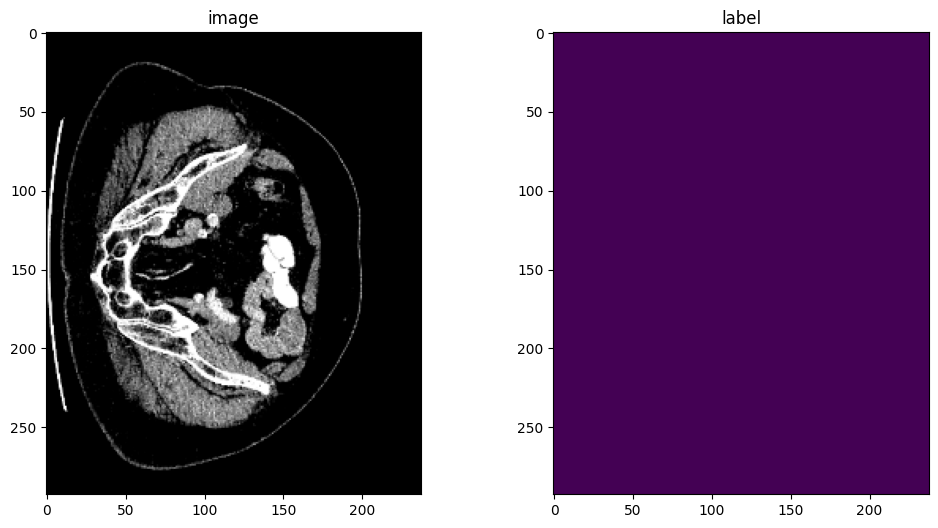

torch.Size([230, 190, 335]) torch.Size([230, 190, 335])


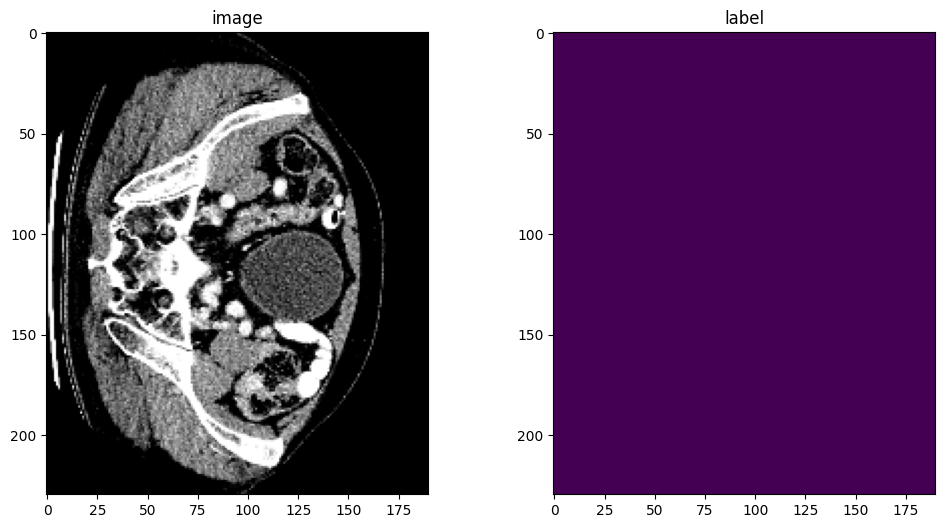

In [38]:
# Verify preprocessing pipeline by loading a few samples
# and visualizing image/label pairs after transformation.

check_ds = Dataset(data=val_files, transform=val_transforms)
check_loader = DataLoader(check_ds, batch_size=1)

check_data = first(check_loader)
image, label = (
    check_data["image"][0][0],
    check_data["label"][0][0]
)

print(f"image shape: {image.shape}, label shape: {label.shape}")

# Display a representative slice from the first volume
plt.figure("check", (12, 6))
plt.subplot(1, 2, 1)
plt.title("image")
plt.imshow(image[:, :, 80], cmap="gray")

plt.subplot(1, 2, 2)
plt.title("label")
plt.imshow(label[:, :, 80])

plt.show()

# Visualize a second sample to confirm transforms
# are applied consistently across the dataset.
for i, batch in enumerate(check_loader):
    if i == 1:
        image = batch["image"][0][0]
        label = batch["label"][0][0]

        print(image.shape, label.shape)

        plt.figure("check", (12, 6))
        plt.subplot(1, 2, 1)
        plt.title("image")
        plt.imshow(image[:, :, 80], cmap="gray")

        plt.subplot(1, 2, 2)
        plt.title("label")
        plt.imshow(label[:, :, 80])

        plt.show()
        break


# Phase 2 — Preprocessing Pipeline & DataLoader
1. Seperate Train and validation transforms
2. Train/Val split from dataset.json
3. DataLoader for both

In [39]:
# Training transforms used for Task03 Liver segmentation.
# Includes preprocessing, patch extraction, padding, and augmentation.

train_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),

        # Standardize voxel spacing and orientation
        Spacingd(
            keys=["image", "label"],
            pixdim=(1.5, 1.5, 2.0),
            mode=("bilinear", "nearest"),
        ),
        Orientationd(keys=["image", "label"], axcodes="RAS"),

        # Normalize CT intensities
        ScaleIntensityRanged(
            keys=["image"],
            a_min=-57,
            a_max=164,
            b_min=0.0,
            b_max=1.0,
            clip=True,
        ),

        # Sample fixed-size training patches
        RandCropByPosNegLabeld(
            keys=["image", "label"],
            label_key="label",
            spatial_size=(96, 96, 96),
            pos=1,
            neg=1,
            num_samples=4,
            image_key="image",
            image_threshold=0,
            allow_smaller=True,
        ),

        # Guarantee consistent patch dimensions
        SpatialPadd(
            keys=["image", "label"],
            spatial_size=(96, 96, 96),
        ),

        # Random left/right augmentation
        RandFlipd(
            keys=["image", "label"],
            prob=0.5,
        ),
    ]
)

# Validation transforms.
# Apply only deterministic preprocessing steps.
val_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0)),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        ScaleIntensityRanged(
            keys=["image"],
            a_min=-57,
            a_max=164,
            b_min=0.0,
            b_max=1.0,
            clip=True,
        ),
    ]
)

In [40]:
# Load dataset metadata and create an 80/20
# train-validation split.

with open(os.path.join(data_dir, "dataset.json")) as f:
    datalist = json.load(f)["training"]

# Convert relative paths from dataset.json into
# absolute paths that MONAI can load directly.
for item in datalist:
    img_path = item["image"].lstrip("./")
    lbl_path = item["label"].lstrip("./")

    item["image"] = os.path.normpath(
        os.path.join(data_dir, img_path)
    )
    item["label"] = os.path.normpath(
        os.path.join(data_dir, lbl_path)
    )

# Reserve 20% of studies for validation.
train_files = datalist[:int(len(datalist) * 0.8)]
val_files = datalist[int(len(datalist) * 0.8):]

In [41]:
# Inspect dataset structure to verify that
# image/label paths were loaded correctly.

print("First item in datalist:")
print(datalist[0])

print(f"Type: {type(datalist[0])}")

First item in datalist:
{'image': 'C:\\DataSets\\Medical_Segmentation_Decathlon\\Task03_Liver\\Task03_Liver\\imagesTr\\liver_14.nii.gz', 'label': 'C:\\DataSets\\Medical_Segmentation_Decathlon\\Task03_Liver\\Task03_Liver\\labelsTr\\liver_14.nii.gz'}
Type: <class 'dict'>


In [42]:
# Create dataset and dataloader for training
# Using MONAI CacheDataset to speed up repeated training iterations
train_ds = CacheDataset(
    data=train_files,
    transform=train_transforms,
    cache_rate=0.3,
    num_workers=4
)

# Quick sanity check to verify dataset loading and transforms
print("Checking training dataset...")
print(f"Total samples in dataset: {len(train_ds)}")

for i in range(len(train_ds)):
    try:
        print(i)
        sample = train_ds[i]

        print(f"\n--- Sample {i} ---")
        print(f"Type of sample: {type(sample)}")
        print(f"Sample: {sample}")

        # Handle MONAI outputs that may return list or dict depending on pipeline
        if isinstance(sample, list):
            print(f"⚠️ Sample is a LIST with {len(sample)} items")
            print(f"Type of first item: {type(sample[0])}")
            if isinstance(sample[0], dict):
                print(f"Keys in first item: {sample[0].keys()}")
            sample = sample[0]

        elif isinstance(sample, dict):
            print(f"✓ Sample is a DICT")
            print(f"Keys: {sample.keys()}")
        else:
            print(f"❌ Unexpected type: {type(sample)}")

        print(f"Image shape: {sample['image'].shape}")
        print(f"Label shape: {sample['label'].shape}")

    except Exception as e:
        print(f"\nERROR loading sample {i}")
        print(f"Image path: {train_files[i]['image']}")
        print(f"Label path: {train_files[i]['label']}")
        print(f"Exception type: {type(e).__name__}")
        print(f"Exception: {e}")
        import traceback
        traceback.print_exc()
        break

    # stop early after a few samples for debugging
    if i == 5:
        break


# Training dataloader (uses padding to handle variable volume sizes)
train_loader = DataLoader(
    train_ds,
    batch_size=4,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
    collate_fn=pad_list_data_collate
)

# Validation dataset and dataloader (no augmentation applied)
val_ds = CacheDataset(
    data=val_files,
    transform=val_transforms,
    cache_rate=0.3,
    num_workers=4
)

val_loader = DataLoader(
    val_ds,
    batch_size=1,
    num_workers=4,
    persistent_workers=True,
    collate_fn=pad_list_data_collate
)

Loading dataset: 100%|██████████| 31/31 [01:02<00:00,  2.02s/it]


Checking training dataset...
Total samples in dataset: 104
0

--- Sample 0 ---
Type of sample: <class 'list'>
Sample: [{'image': metatensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 1.0000, 1.0000, 1.0000],
          [0.0000, 0.0000, 0.0000,  ..., 1.0000, 1.0000, 1.0000],
          [0.0000, 0.0000, 0.0000,  ..., 1.0000, 1.0000, 1.0000]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 1.0000, 1.0000, 1.0000],
          [0.0000, 0.0000, 0.0000,  ..., 1.0000, 1.0000, 1.0000],
          [0.0000, 0.0000, 0.0000,  ..., 1.0000, 1.0000, 1.0000]],

         [[0.0000, 0.0000, 0.0000,  ..., 

Loading dataset: 100%|██████████| 8/8 [00:15<00:00,  1.90s/it]


# Phase 3 — Model Architecture & Experiment Tracking
- Define model
- setup MLflow

In [43]:
# Move model to GPU
device = torch.device("cuda:0")

# 3D UNet for volumetric medical image segmentation
# Output channels = 3 (background, liver, tumor)
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=3,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
    norm=Norm.BATCH,
).to(device)

# Load pretrained weights if available (fine-tuning setup)
if os.path.exists("checkpoints/best_model.pth"):
    print("Loading best model from checkpoint...")
    model.load_state_dict(torch.load("checkpoints/best_model_liver_6_19.pth"))
    model.eval()

# Loss designed for class imbalance and small tumor regions
tversky_loss = TverskyLoss(
    to_onehot_y=True,
    softmax=True,
    alpha=0.3,
    beta=0.7
)

# Weighted Dice + Cross-Entropy for stable multi-class training
dice_ce_loss = DiceCELoss(
    to_onehot_y=True,
    softmax=True,
    weight=torch.tensor([0.1, 0.5, 3.0]).to(device)
)

# Combined loss to balance segmentation quality and tumor sensitivity
def combined_loss(pred, label):
    return 0.5 * tversky_loss(pred, label) + 0.5 * dice_ce_loss(pred, label)

# Optimizer setup
optimizer = torch.optim.Adam(model.parameters(), 1e-5)

# Training schedule
max_epochs = 300

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=max_epochs,
    eta_min=1e-6
)

# Dice metric for evaluation (ignores background class)
dice_metric = DiceMetric(include_background=False, reduction="mean")

In [44]:
# Set MLflow experiment for tracking training runs
mlflow.set_experiment("liver-segmentation")

# Ensure proper cleanup of any previous runs
mlflow.end_run()

# # Phase 4 — Training Loop
- training loop
- postprocessing

In [45]:
# Convert model outputs into discrete class predictions
# and prepare labels for Dice evaluation (3-class problem)
post_pred = AsDiscrete(argmax=True, to_onehot=3)
post_label = AsDiscrete(to_onehot=3)

In [ ]:
# Training configuration
from pathlib import Path

best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []

training_mode = True

max_epochs = 3 # temp
val_interval = 5

# Load pretrained checkpoint for fine-tuning
model.load_state_dict(
    torch.load("checkpoints/best_model_liver_6_19.pth"),
    strict=False
)

# Configure MLflow tracking URI for local logging
def ensure_tracking_uri(local_mlruns_dir="mlruns"):
    uri = mlflow.get_tracking_uri()
    print("Current MLflow tracking URI:", uri)

    if uri.startswith("http"):
        return

    file_uri = Path(local_mlruns_dir).resolve().as_uri()
    mlflow.set_tracking_uri(file_uri)
    print("Using local MLflow file store:", file_uri)

# Safe MLflow artifact logging
def safe_log_artifact(local_path, artifact_path=None):
    try:
        mlflow.log_artifact(local_path, artifact_path)
    except MlflowException as e:
        print("Artifact logging failed:", e)
        print("Saved locally at:", os.path.abspath(local_path))

ensure_tracking_uri()

# Main training loop with MLflow tracking
if training_mode:
    with mlflow.start_run():

        # Log experiment hyperparameters
        mlflow.log_params({
            "model": "UNet",
            "epochs": max_epochs,
            "batch_size": 2,
            "learning_rate": 1e-4,
            "patch_size": "96x96x96",
            "dataset": "Task03_Liver",
            "out_channels": 3
        })

        for epoch in range(max_epochs):
            model.train()
            epoch_loss = 0

            # Training step
            for batch_data in train_loader:
                inputs = batch_data["image"].to(device)
                labels = batch_data["label"].to(device)

                optimizer.zero_grad()
                outputs = model(inputs)
                loss = combined_loss(outputs, labels)
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()

            scheduler.step()

            # Log learning rate
            mlflow.log_metric("learning_rate", scheduler.get_last_lr()[0], step=epoch)

            epoch_loss /= len(train_loader)
            epoch_loss_values.append(epoch_loss)

            # Log training loss
            mlflow.log_metric("train_loss", epoch_loss, step=epoch)
            print(f"Epoch {epoch+1}/{max_epochs} — loss: {epoch_loss:.4f}")

            # Validation step
            if (epoch + 1) % val_interval == 0:
                model.eval()

                with torch.no_grad():
                    for val_data in val_loader:
                        val_inputs = val_data["image"].to(device)
                        val_labels = val_data["label"].to(device)

                        val_outputs = sliding_window_inference(
                            val_inputs, (96, 96, 96), 4, model
                        )

                        val_outputs = [post_pred(i) for i in decollate_batch(val_outputs)]
                        val_labels = [post_label(i) for i in decollate_batch(val_labels)]

                        dice_metric(y_pred=val_outputs, y=val_labels)

                    metric = dice_metric.aggregate().item()
                    dice_metric.reset()

                    metric_values.append(metric)

                    mlflow.log_metric("val_dice", metric, step=epoch)
                    print(f"Val Dice: {metric:.4f}")

                    # Save best performing model
                    if metric > best_metric:
                        best_metric = metric
                        best_metric_epoch = epoch + 1

                        torch.save(model.state_dict(), "checkpoints/best_model_liver.pth")
                        mlflow.log_artifact("checkpoints/best_model_liver.pth")

                        print(f"New best model — Dice: {best_metric:.4f}")

        print(f"Training complete. Best Dice: {best_metric:.4f}")
        mlflow.log_metric("best_val_dice", best_metric)

Current MLflow tracking URI: file:///D:/Summer_Projects_2026/ct-segmentation-monai/mlruns
Using local MLflow file store: file:///D:/Summer_Projects_2026/ct-segmentation-monai/mlruns
Epoch 1/3 — loss: 0.5901
Epoch 2/3 — loss: 0.5894
Epoch 3/3 — loss: 0.5462
Training complete. Best Dice: -1.0000


In [47]:
# Verify training and validation dataset paths before training

print("Verifying training data paths...")

# training set summary
print(f"Number of training files: {len(train_files)}")
print(f"First training image path: {train_files[0]['image']}")
print(f"Path exists: {os.path.exists(train_files[0]['image'])}")

print()

# validation set summary
print(f"Number of validation files: {len(val_files)}")
print(f"First validation image path: {val_files[0]['image']}")
print(f"Path exists: {os.path.exists(val_files[0]['image'])}")

Verifying training data paths...
Number of training files: 104
First training image path: C:\DataSets\Medical_Segmentation_Decathlon\Task03_Liver\Task03_Liver\imagesTr\liver_14.nii.gz
Path exists: True

Number of validation files: 27
First validation image path: C:\DataSets\Medical_Segmentation_Decathlon\Task03_Liver\Task03_Liver\imagesTr\liver_37.nii.gz
Path exists: True


# Phase 4 — Inference & Explainability

In [48]:
# Load the best saved checkpoint

# Load best performing weights
model.load_state_dict(torch.load("checkpoints/best_model_liver_6_19.pth"))
model.eval()

UNet(
  (model): Sequential(
    (0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
          (adn): ADN(
            (N): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (adn): ADN(
            (N): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    )
    (1): SkipConnection(
      (submodule): Sequential(
        (0): ResidualUnit(
          (conv): Sequential(


In [49]:
# Run inference on a validation volume using sliding window approach

val_data = first(val_loader)
val_input = val_data["image"]
val_label = val_data["label"]

# Perform sliding window inference for large 3D volume
start = time.time()
with torch.no_grad():
    val_output = sliding_window_inference(
        val_input.to(device),
        (96, 96, 96),
        4,
        model,
        overlap=0.7,
        mode="gaussian"
    )

print(f"Inference time: {time.time() - start:.2f}s")

Inference time: 0.61s


In [50]:
# Post-process predictions and select representative slice for visualization

slice_idx = 186  # initial reference slice

# convert logits to class predictions
val_output_discrete = torch.argmax(val_output, dim=1, keepdim=True)

# keep only largest connected components (remove noise)
keep_largest = KeepLargestConnectedComponent(applied_labels=[1, 2])
val_output_cleaned = keep_largest(val_output_discrete[0])

vol = val_output_cleaned[0].cpu().numpy()

# identify slices containing predicted structures
target_slices = [
    i for i in range(vol.shape[2])
    if vol[:, :, i].sum() > 0
]

print(f"Volume depth: {vol.shape[2]}")
print(f"Slices with liver/tumor: {target_slices[:10]}...")

# choose central informative slice
if target_slices:
    slice_idx = target_slices[len(target_slices) // 2]
else:
    slice_idx = vol.shape[2] // 2

print(f"Visualizing slice: {slice_idx}")

# extract CT, ground truth, and prediction slices
slice_ct = val_input[0, 0, :, :, slice_idx].cpu().numpy()
slice_label = val_label[0, 0, :, :, slice_idx].cpu().numpy()
slice_pred = vol[:, :, slice_idx]

# recompute predictions (ensures consistency after post-processing)
val_output_discrete = torch.argmax(val_output, dim=1, keepdim=True)

keep_largest = KeepLargestConnectedComponent(applied_labels=[1, 2])
val_output_cleaned = keep_largest(val_output_discrete[0])

slice_pred = val_output_cleaned[0, :, :, slice_idx].cpu().numpy()

Volume depth: 62
Slices with liver/tumor: [12, 13, 14, 15, 16, 17, 18, 19, 20, 21]...
Visualizing slice: 36


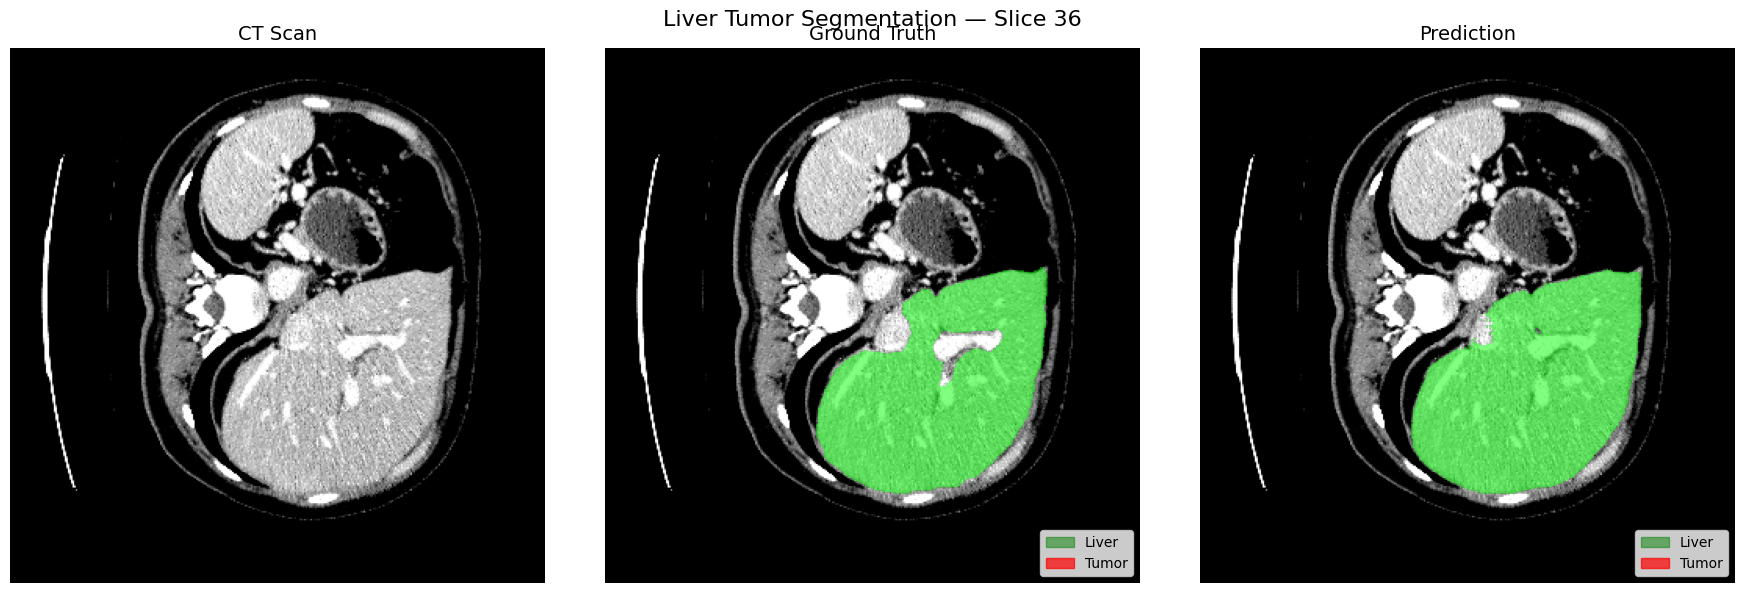

In [51]:
# color coded visualization — 3 class (background / liver / tumor)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

slice_ct = val_input[0, 0, :, :, slice_idx].cpu().numpy()
slice_label = val_label[0, 0, :, :, slice_idx].cpu().numpy()
slice_pred = val_output_cleaned[0, :, :, slice_idx].cpu().numpy()

# build RGBA overlays for ground truth
gt_overlay = np.zeros((*slice_label.shape, 4))
gt_overlay[slice_label == 1] = [0, 1, 0, 0.5]    # green = liver
gt_overlay[slice_label == 2] = [1, 0, 0, 0.7]    # red = tumor

# build RGBA overlays for prediction
pred_overlay = np.zeros((*slice_pred.shape, 4))
pred_overlay[slice_pred == 1] = [0, 1, 0, 0.5]   # green = liver
pred_overlay[slice_pred == 2] = [1, 0, 0, 0.7]   # red = tumor

# Panel 1: raw CT
axes[0].imshow(slice_ct, cmap="gray")
axes[0].set_title("CT Scan", fontsize=14)
axes[0].axis("off")

# Panel 2: ground truth overlay
axes[1].imshow(slice_ct, cmap="gray")
axes[1].imshow(gt_overlay)
axes[1].set_title("Ground Truth", fontsize=14)
axes[1].axis("off")
green_patch = mpatches.Patch(color="green", alpha=0.5, label="Liver")
red_patch = mpatches.Patch(color="red", alpha=0.7, label="Tumor")
axes[1].legend(handles=[green_patch, red_patch], loc="lower right")

# Panel 3: prediction overlay
axes[2].imshow(slice_ct, cmap="gray")
axes[2].imshow(pred_overlay)
axes[2].set_title("Prediction", fontsize=14)
axes[2].axis("off")
axes[2].legend(handles=[green_patch, red_patch], loc="lower right")

plt.suptitle(f"Liver Tumor Segmentation — Slice {slice_idx}", fontsize=16)
plt.tight_layout()
plt.savefig("prediction_overlay.png", dpi=150, bbox_inches="tight")
mlflow.log_artifact("prediction_overlay.png")
plt.show()

In [52]:
#final evaluation on validation set using best model
model.eval()
dice_scores = []

with torch.no_grad():
    for val_data in val_loader:
        val_input = val_data["image"].to(device)
        val_label = val_data["label"].to(device)
        
        val_output = sliding_window_inference(
            val_input, (96, 96, 96), 4, model, overlap=0.5
        )
        
        val_output_post = [post_pred(i) for i in decollate_batch(val_output)]
        val_label_post = [post_label(i) for i in decollate_batch(val_label)]
        
        dice_metric(y_pred=val_output_post, y=val_label_post)

final_dice = dice_metric.aggregate().item()
dice_metric.reset()
print(f"Final Validation Dice: {final_dice:.4f}")
mlflow.log_metric("final_val_dice", final_dice)

Final Validation Dice: 0.6980
